In [88]:
import matplotlib.pyplot as plt
import pandas as pd
state_df = pd.read_csv("State_data.csv")

**Section-1 : Spatial aggregation.**

Q1: State with Highest Average PM2.5

In [92]:
df = pd.read_csv("Data.csv")

# Convert date
df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True, errors='coerce')


state_avg = df.groupby('State')['PM2.5'].mean()

# Get highest
highest_state = state_avg.idxmax()
highest_value = state_avg.max()

print(highest_state, highest_value)

Delhi 103.15680337784858


Q2 Most Hazardous Days (PM2.5 > 300 in 2023)

In [93]:
df_2023 = df[df['Timestamp'].dt.year == 2023]

# Hazardous condition
hazard = df_2023[df_2023['PM2.5'] > 300]

# Count per state
hazard_count = hazard.groupby('State').size()

# Get highest
state_hazard = hazard_count.idxmax()
count_hazard = hazard_count.max()

print(state_hazard, 'has the most hazardous days in 2023 = ', count_hazard)

Delhi has the most hazardous days in 2023 =  5


Q3  Highest Variability (Standard Deviation) in 2023

In [94]:
# Filter for 2023
df_2023 = df[df['Timestamp'].dt.year == 2023]
state_std = df_2023.groupby('State')['PM2.5'].std()

# Get state with highest variability
state_var = state_std.idxmax()
var_value = state_std.max()

print(state_var, var_value)

Delhi 70.05931302465851


Q4 Lowest Average PM2.5 (2021–2022)

In [14]:
# Filter for 2021 and 2022
df_postcovid = df[df['Timestamp'].dt.year.isin([2021, 2022])]

# Calculate average PM2.5
state_avg_post = df_postcovid.groupby('State')['PM2.5'].mean()

# Get lowest
state_low = state_avg_post.idxmin()
low_value = state_avg_post.min()

print(state_low, low_value)

Mizoram 11.150729196695943


**Section-2 : Temporal Aggregation**

Q1  Station with highest PM2.5 in Aug 2021

In [96]:
# Filter for August 2021
aug_2021 = df[(df['Timestamp'].dt.year == 2021) & 
              (df['Timestamp'].dt.month == 8)]

# Get max PM2.5 row
max_row = aug_2021.loc[aug_2021['PM2.5'].idxmax()]

station_name = max_row['Station']
max_val = max_row['PM2.5']

print(f"{station_name} recorded the highest PM2.5 in Aug 2021 with {max_val}")

Anand Vihar, Delhi - DPCC recorded the highest PM2.5 in Aug 2021 with 68.15822050290136


Q2: Seasonal Average (2022) – Lal Bahadur Shastri Nagar

In [98]:
# Filter station
station_df = df[df['Station'] == "Lal Bahadur Shastri Nagar, Kalaburagi - KSPCB"]


station_2022 = station_df[station_df['Timestamp'].dt.year == 2022].copy()

# Create month column
station_2022['Month'] = station_2022['Timestamp'].dt.month

# Function to assign season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Other'

station_2022['Season'] = station_2022['Month'].apply(get_season)




season_avg = station_2022.groupby('Season')['PM2.5'].mean()

print(season_avg)

# Highest season
print("\nHighest Pollution Season:", season_avg.idxmax())

Season
Monsoon    12.977099
Other      49.963363
Summer     44.061560
Winter     52.458378
Name: PM2.5, dtype: float64

Highest Pollution Season: Winter


Q3 Weekday vs Weekend Comparison (2021) + Plot

Type     Weekday    Weekend
Month                      
1       0.000000  64.919865
2       0.000000  54.134404
3      53.022158   0.000000
4      41.681557   0.000000
5      16.130454   0.000000
6      10.419060   0.000000
7       0.000000   8.921638
8       0.000000   0.000000
9       0.000000   0.000000
10      0.000000  59.525939
11     46.193449   0.000000
12     78.872001   0.000000


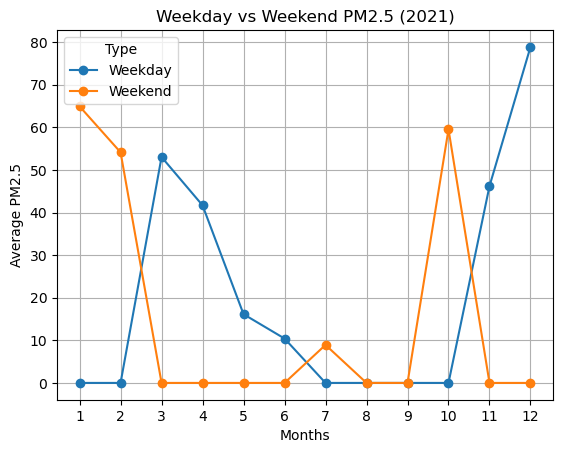

In [20]:
# Filter properly with copy()
station_2021 = df[(df['Station'] == "Lal Bahadur Shastri Nagar, Kalaburagi - KSPCB") &
                  (df['Timestamp'].dt.year == 2021)].copy()

# Create columns
station_2021['Month'] = station_2021['Timestamp'].dt.month
station_2021['Day'] = station_2021['Timestamp'].dt.dayofweek

# Weekday / Weekend
station_2021['Type'] = station_2021['Day'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Monthly average
monthly_avg = station_2021.groupby(['Month', 'Type'])['PM2.5'].mean().unstack().fillna(0)

print(monthly_avg)





# plot
monthly_avg = monthly_avg.reindex(range(1,13), fill_value=0)

monthly_avg.plot(marker='o')

plt.xlabel("Months")
plt.ylabel("Average PM2.5")
plt.title("Weekday vs Weekend PM2.5 (2021)")
plt.xticks(range(1,13))
plt.grid()

plt.show()

**Section-3 : Population-Based**

Q1 Stations relative to population

In [48]:

state_df = pd.read_csv("State_data.csv")
# Count stations per state
stations_count = df.groupby('State')['Station'].nunique()

# Merge with state data
merged = state_df.copy()
merged['Stations'] = merged['State'].map(stations_count)

# Calculate stations per population
merged['Stations_per_Person'] = merged['Stations'] / merged['Population']

# Get highest
state_max = merged.loc[merged['Stations_per_Person'].idxmax()]

print(state_max['State'], state_max['Stations_per_Person'])

Chandigarh 2.8423895021081055e-06


Q2 Top 5 polluted states (per capita PM2.5, 2023)

                State  Per_Capita_PM
29         Chandigarh       0.000057
30             Sikkim       0.000025
22            Tripura       0.000022
27         Puducherry       0.000020
26  Arunachal Pradesh       0.000017


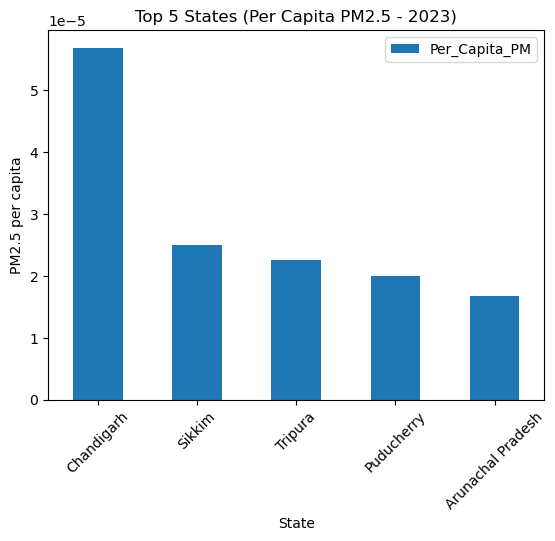

In [99]:


# Filter 2023
df_2023 = df[df['Timestamp'].dt.year == 2023]

# Average PM2.5 per state
state_pm = df_2023.groupby('State')['PM2.5'].mean()

# Merge with population
merged2 = state_df.copy()
merged2['PM2.5'] = merged2['State'].map(state_pm)

# Per capita pollution
merged2['Per_Capita_PM'] = merged2['PM2.5'] / merged2['Population']

# Top 5
top5 = merged2.sort_values('Per_Capita_PM', ascending=False).head(5)

print(top5[['State', 'Per_Capita_PM']])





top5.plot(x='State', y='Per_Capita_PM', kind='bar')

plt.title("Top 5 States (Per Capita PM2.5 - 2023)")
plt.ylabel("PM2.5 per capita")
plt.xticks(rotation=45)

plt.show()

Q3   Population Density vs PM2.5 (Scatter Plot)

Index(['State', 'Population', 'Area'], dtype='object')


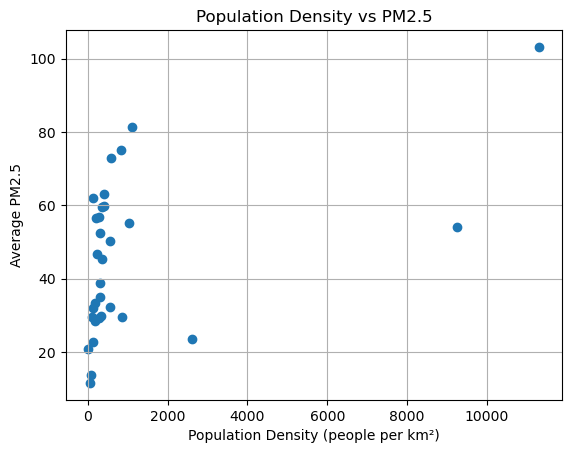

In [100]:

print(state_df.columns)   # Check once
state_df.columns = ['State', 'Population', 'Area']

# Calculate population density
state_df['Density'] = state_df['Population'] / state_df['Area']

# Calculate average PM2.5 for each state (all years)
state_pm = df.groupby('State')['PM2.5'].mean()

# Merge data
merged = state_df.copy()
merged['PM2.5'] = merged['State'].map(state_pm)

# Remove missing values
merged = merged.dropna()







# Scatter plot
plt.figure()

plt.scatter(merged['Density'], merged['PM2.5'])

plt.xlabel("Population Density (people per km²)")
plt.ylabel("Average PM2.5")
plt.title("Population Density vs PM2.5")

plt.grid()

plt.show()

**Section-4  Area Based**

Q1  Highest PM2.5 per square km

Chandigarh 0.47328027309179677


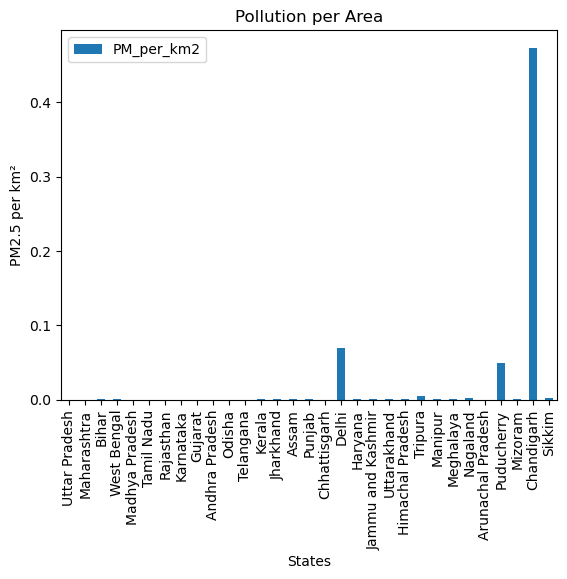

In [89]:


# Ensure correct column names
state_df.columns = ['State', 'Population', 'Area']

# Average PM2.5 per state
state_pm = df.groupby('State')['PM2.5'].mean()

# Merge
merged = state_df.copy()
merged['PM2.5'] = merged['State'].map(state_pm)

# Calculate PM2.5 per area
merged['PM_per_km2'] = merged['PM2.5'] / merged['Area']

# Drop missing
merged = merged.dropna()

# Find highest
max_state = merged.loc[merged['PM_per_km2'].idxmax()]
print(max_state['State'], max_state['PM_per_km2'])




merged.plot(x='State', y='PM_per_km2', kind='bar')

plt.xlabel("States")
plt.ylabel("PM2.5 per km²")
plt.title("Pollution per Area")

plt.xticks(rotation=90)
plt.show()

Q2  Monitoring stations per square km

Delhi 0.026954177897574125


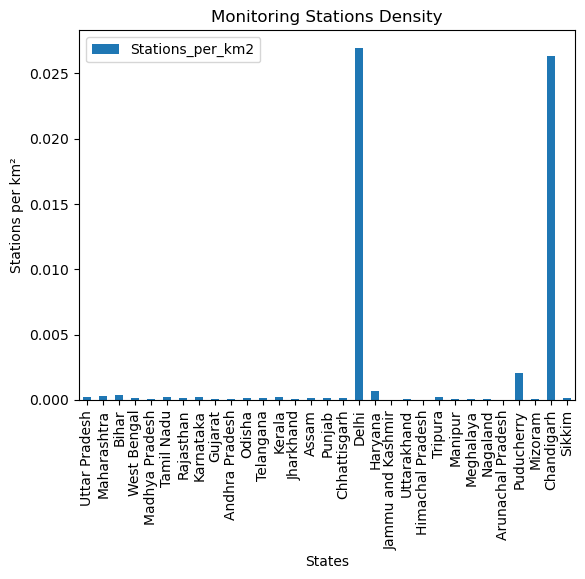

In [63]:
# Count stations
stations_count = df.groupby('State')['Station'].nunique()

# Merge
merged2 = state_df.copy()
merged2['Stations'] = merged2['State'].map(stations_count)

# Stations per area
merged2['Stations_per_km2'] = merged2['Stations'] / merged2['Area']

# Drop missing
merged2 = merged2.dropna()




# Find highest
max_station_state = merged2.loc[merged2['Stations_per_km2'].idxmax()]

print(max_station_state['State'], max_station_state['Stations_per_km2'])



merged2.plot(x='State', y='Stations_per_km2', kind='bar')

plt.xlabel("States")
plt.ylabel("Stations per km²")
plt.title("Monitoring Stations Density")

plt.xticks(rotation=90)
plt.show()

**Section-5 : Funding Based**

Q1    PM2.5 (Funded vs Non-Funded states in 2021)

In [101]:
df = pd.read_csv("Data.csv")
fund_df = pd.read_csv("NCAP_Funding.csv")

# Convert date
df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True, errors='coerce')
df_2021 = df[df['Timestamp'].dt.year == 2021]

# Average PM2.5 per state
pm_2021 = df_2021.groupby('State')['PM2.5'].mean()

# Get states with funding
funded_states = fund_df['State'].unique()

# Create comparison dataframe
compare = pd.DataFrame({'PM2.5': pm_2021})
compare['Funded'] = compare.index.isin(funded_states)


#  Compare averages
result = compare.groupby('Funded')['PM2.5'].mean()

print(result)

Funded
False    33.693814
True     48.962342
Name: PM2.5, dtype: float64


Q2   Time Series (Assam + Funding vs PM2.5)

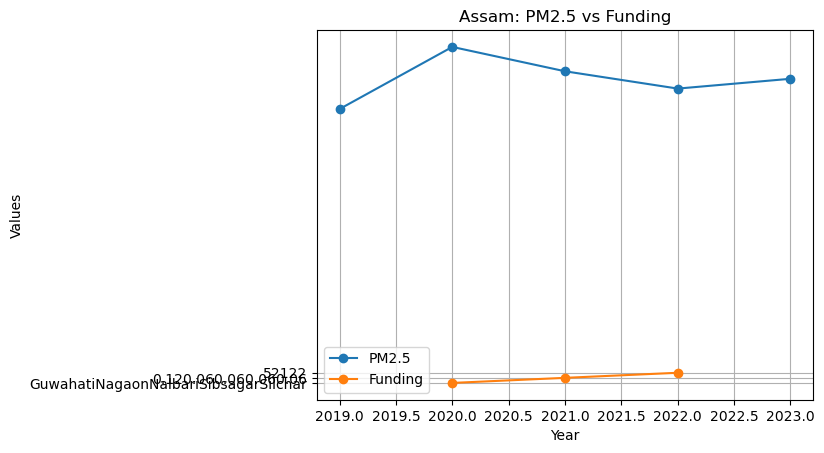

In [90]:

df = pd.read_csv("Data.csv")
fund_df = pd.read_csv("NCAP_Funding.csv")


df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True, errors='coerce')


fund_df.columns = fund_df.columns.str.strip()


assam_df = df[df['State'] == 'Assam'].copy()

# Sort and create year
assam_df = assam_df.sort_values('Timestamp')
assam_df['Year'] = assam_df['Timestamp'].dt.year

# Yearly PM2.5
assam_pm = assam_df.groupby('Year')['PM2.5'].mean()





#  Assam Funding Data


assam_fund = fund_df[fund_df['State'] == 'Assam']

# Use safe column indexing (NO ERROR METHOD)
funding = [
    assam_fund.iloc[:, 2].sum(),  # 2019-20
    assam_fund.iloc[:, 3].sum(),  # 2020-21
    assam_fund.iloc[:, 4].sum()   # 2021-22
]

years = [2020, 2021, 2022]






 # Plot

plt.figure()

plt.plot(assam_pm.index, assam_pm.values, marker='o', label='PM2.5')
plt.plot(years, funding, marker='o', label='Funding')

plt.xlabel("Year")
plt.ylabel("Values")
plt.title("Assam: PM2.5 vs Funding")

plt.legend()
plt.grid()

plt.show()

Q3: Area vs Funding (Scatter Plot)

Using column: Total fund released
            State  Funding
0   Uttar Pradesh    76.94
1     Maharashtra    63.15
2           Bihar    21.60
3     West Bengal    19.00
4  Madhya Pradesh    27.14


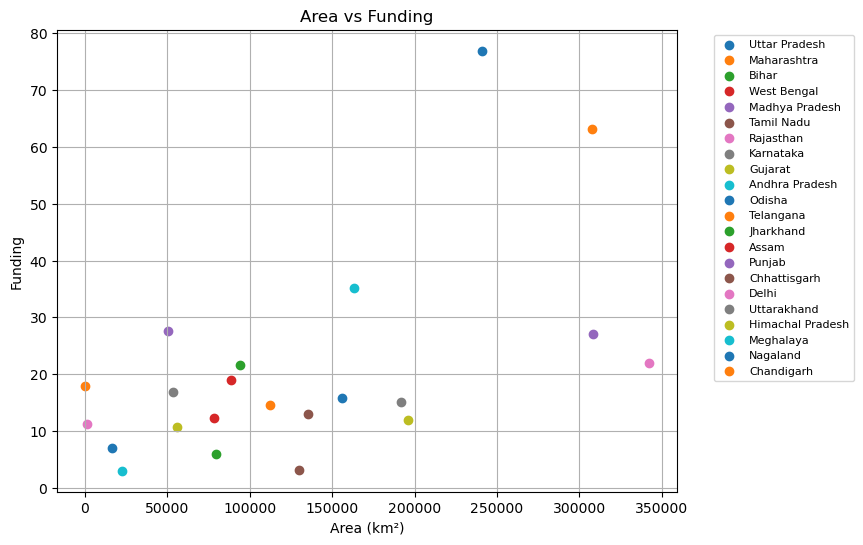

In [91]:

fund_df = pd.read_csv("NCAP_Funding.csv")
state_df = pd.read_csv("State_data.csv")



fund_df.columns = fund_df.columns.str.strip()
state_df.columns = ['State', 'Population', 'Area']



total_col = [col for col in fund_df.columns if "Total" in col][0]

print("Using column:", total_col)

# Convert to numeric
fund_df[total_col] = (
    fund_df[total_col]
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

fund_df[total_col] = pd.to_numeric(fund_df[total_col], errors='coerce')

# Funding per state
state_fund = fund_df.groupby('State')[total_col].sum()





merged = state_df.copy()
merged['Funding'] = merged['State'].map(state_fund)

merged = merged.dropna()







print(merged[['State', 'Funding']].head())

# Plot
plt.figure(figsize=(8,6))

for _, row in merged.iterrows():
    plt.scatter(row['Area'], row['Funding'], label=row['State'])

plt.xlabel("Area (km²)")
plt.ylabel("Funding")
plt.title("Area vs Funding")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid()

plt.show()